In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy

np.random.seed(378)

In [2]:
#general function for taking a step in a Markov chain with a finite number of states,
#takes as input the current state and the probability transition matrix

def step(current, T_matrix):

    cumul_prob = np.cumsum(T_matrix[current])
    p = np.random.random() #extracting random number between 0 and 1
    
    for i in range(len(cumul_prob)):
        if p <= cumul_prob[i]:
            return i
        else:
            continue

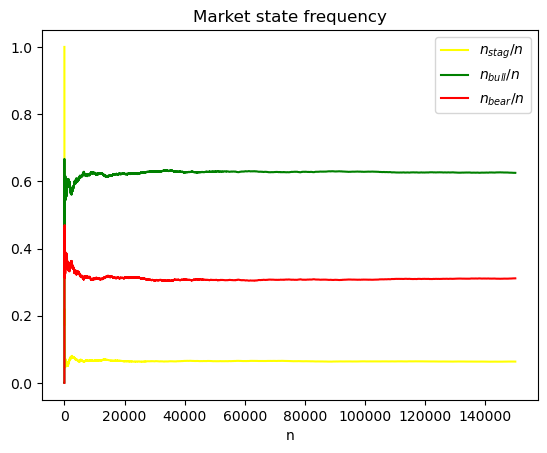

In [19]:

# 0 = stagnation, 1 = bull, 2 = bear

N = 150000 #steps in the chain
T_matrix = [[0.5, 0.25, 0.25], [0.025, 0.9, 0.075], [0.05, 0.15, 0.8]] #transition prob matrix

n_stag, n_bull, n_bear = 0, 0, 0
stag_freq = []
bull_freq = []
bear_freq = []

current = 0 #initial state (in this case stagnation)
n_stag += 1

n_vals = np.arange(2, N)

#running the Markov chain  
for n in n_vals:
    
    current = step(current, T_matrix)
    if current == 0:
        n_stag += 1
    elif current == 1:
        n_bull += 1
    else:
        n_bear += 1    
    
    stag_freq.append(n_stag/n)
    bull_freq.append(n_bull/n)
    bear_freq.append(n_bear/n)
    


#trace plot of the frequencies
plt.plot(n_vals, stag_freq, c='yellow', label='$n_{stag}/n$')
plt.plot(n_vals, bull_freq, c='green', label='$n_{bull}/n$')
plt.plot(n_vals, bear_freq, c='red', label='$n_{bear}/n$')
plt.xlabel('n')
plt.title('Market state frequency')
plt.legend()






Text(0.5, 1.0, 'Distribution of the bull market frequencies')

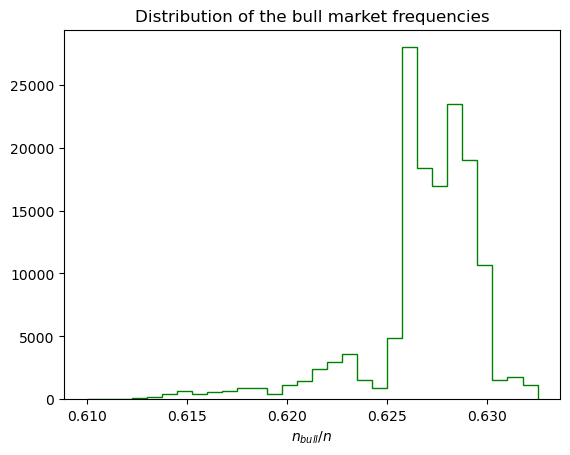

In [20]:
burn_in = 5000 # ~number of steps to reach stationarity

#plotting the distribution of the values, discarding the burn in
plt.hist(bull_freq[burn_in:], 30, color='green', histtype='step')
plt.xlabel('$n_{bull}/n$')
plt.title('Distribution of the bull market frequencies')

In [21]:
#computing the mean and standard deviation as summary statistics for the distribution
mean = np.mean(bull_freq[burn_in:])
err = np.std(bull_freq[burn_in:])

#our best numerical estimate for the probability of the market being in bull state
print(str(mean)+' +- '+str(err))

0.6268371286495275 +- 0.0029292165119400772
